In [32]:
#Código
import numpy as np
import matplotlib.pyplot as plt
# -----------------------------
# 1. Datos de entrada
# -----------------------------
# x1: palabras sospechosas
# x2: links
# x3: mayúsculas
# x4: longitud normalizada

# array de características (6 muestras, 4 características)

X = np.array([
    [0, 0, 0.1, 0.2],
    [1, 0, 0.2, 0.3],
    [2, 1, 0.3, 0.4],
    [3, 1, 0.5, 0.6],
    [4, 2, 0.7, 0.8],
    [5, 3, 0.9, 0.9]
])

y = np.array([0, 0, 0, 1, 1, 1]) # etiquetas (0: no spam, 1: spam) de cada muestra


2. Preparar datos

In [33]:
n_samples, n_features = X.shape # número de muestras y características en el dataset


# Añadir columna de 1s (bias → b0) a la matriz de características
X = np.hstack((np.ones((n_samples, 1)), X))

# Inicializar parámetros (b0, b1, b2, b3, b4) de la regresión logística a cero
w = np.zeros(n_features + 1)




3. Función sigmoide

In [34]:
# Función sigmoide para convertir la salida lineal en probabilidad entre 0 y 1
# z = w0*1 + w1*x1 + w2*x2 + w3*x3 + w4*x4 => z = w^T * x (donde x incluye el bias) 

def sigmoid(z):
    return 1 / (1 + np.exp(-z))




4. Función de costo (log-loss)

In [35]:
# Función de costo (log-loss) para evaluar el rendimiento del modelo

def compute_cost(X, y, w):
    z = X @ w
    p = sigmoid(z)
    
    # evitar log(0) con un pequeño valor epsilon
    eps = 1e-9 
    
    # costo log-loss: -1/m * sum(y*log(p) + (1-y)*log(1-p))
    
    cost = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)) 
    return cost



5. Descenso de gradiente

In [36]:
# Gradiente descendente para optimizar los parámetros w
# lr: tasa de aprendizaje, epochs: número de iteraciones

def gradient_descent(X, y, w, lr=0.1, epochs=1000):
    for i in range(epochs):
        z = X @ w
        p = sigmoid(z)
        
        # Gradiente
        grad = (X.T @ (p - y)) / len(y)
        
        # Actualización de parámetros
        w = w - lr * grad
        
        # Mostrar avance
        if i % 100 == 0:
            print(f"Iter {i} - Costo: {compute_cost(X, y, w):.4f}")
    
    return w


6. Entrenamiento

In [37]:
w = gradient_descent(X, y, w, lr=0.1, epochs=1000)

Iter 0 - Costo: 0.6282
Iter 100 - Costo: 0.3281
Iter 200 - Costo: 0.2515
Iter 300 - Costo: 0.2127
Iter 400 - Costo: 0.1878
Iter 500 - Costo: 0.1696
Iter 600 - Costo: 0.1554
Iter 700 - Costo: 0.1438
Iter 800 - Costo: 0.1340
Iter 900 - Costo: 0.1255


7. Resultados

In [38]:
print("\nParámetros aprendidos:")
print("b0:", w[0])
print("b1, b2, b3, b4:", w[1:])
b0=w[0]
b1=w[1]
b2=w[2]
b3=w[3]
b4=w[4] 



Parámetros aprendidos:
b0: -5.040794609022753
b1, b2, b3, b4: [ 2.00785145  0.17855021  0.43829161 -0.09682416]


8. Predicción

In [39]:
def predict(X, w):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    probs = sigmoid(X @ w)
    return (probs)

y_prob = predict(X[:,1:], w)
print("\nProbabilidades:", y_prob)

y_pred = np.round(y_prob);

print("\nPredicciones:", y_pred)



Probabilidades: [0.00658516 0.04859903 0.31999742 0.78957429 0.97280251 0.99710374]

Predicciones: [0. 0. 0. 1. 1. 1.]


9. Frontera de decisión (fijamos x2 y x4)

In [30]:
x2_fixed = np.mean(X[:,1])
x4_fixed = np.mean(X[:,3])

x1_vals = np.linspace(0,5,100)


In [10]:
# despejamos x3 de:
# b0 + b1*x1 + b2*x2 + b3*x3 + b4*x4 = 0
x3_vals = -(b0 + b1*x1_vals + b2*x2_fixed + b4*x4_fixed) / b3


Gráfica

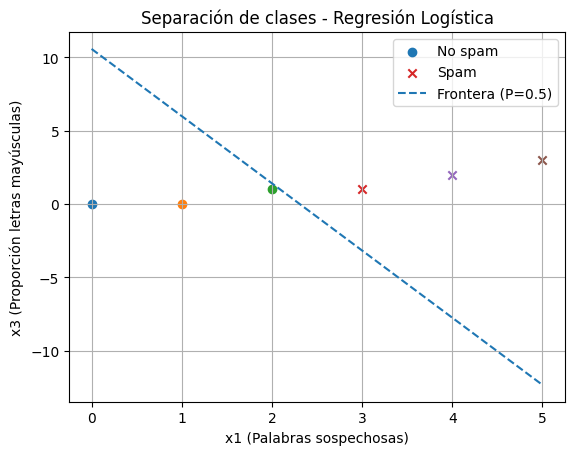

In [11]:
plt.figure()

# Puntos reales
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i,1], X[i,2], marker='o', label='No spam' if i==0 else "")
    else:
        plt.scatter(X[i,1], X[i,2], marker='x', label='Spam' if i==3 else "")

# Frontera de decisión
plt.plot(x1_vals, x3_vals, linestyle='--', label='Frontera (P=0.5)')

plt.xlabel("x1 (Palabras sospechosas)")
plt.ylabel("x3 (Proporción letras mayúsculas)")
plt.title("Separación de clases - Regresión Logística")
plt.legend()
plt.grid()

plt.show()
 
